# Parameter learning for RockSample

In [ ]:
%%capture

import math
import random
import time
import tqdm

from copy import copy

import jax
import jax.numpy as jnp

import numpy as np
from scipy.special import softmax

try:
  import numpyro
except:
  !pip install numpyro
  import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam

from numpyro.infer import MCMC, NUTS

import matplotlib.pyplot as plt
from scipy.stats import gamma, expon, lognorm, bernoulli
import scipy.stats as stats
from scipy.optimize import minimize_scalar

numpyro.set_host_device_count(4)

## Problem definition

* A crawler moves from left to right through a grid.
* If there is a rock in a cell, the agent can sample the rock.
  * If the rock is good, the reward is positive.
  * If the rock is bad, the reward is negative.
* The crawler can sense a rock remotely, with observation noise.

## Sensing Models in POMDPs: Mathematical Formulation

### Sensing Probability Formula

The probability of correctly sensing a rock's quality at distance $d$ is given by:

$$p(d, \text{sensi}) = 0.5 + 0.5 \cdot e^{-\frac{d \cdot \ln(2)}{\text{sensi}}}$$

Where:
- $d = \sqrt{(x - x_{\text{rock}})^2 + (y - y_{\text{rock}})^2}$ is the Euclidean distance
- $\text{sensi}$ is the sensitivity parameter
- $\ln(2)$ is the natural logarithm of 2 (approximately 0.693)

### Mathematical Properties

This formula has key properties that make it suitable for POMDP sensing:

1. **Perfect accuracy at zero distance**:  
   When $d = 0$: $p(0, \text{sensi}) = 0.5 + 0.5 \cdot e^0 = 1.0$

2. **75% accuracy at distance = sensi**:  
   When $d = \text{sensi}$: $p(\text{sensi}, \text{sensi}) = 0.5 + 0.5 \cdot e^{-\ln(2)} = 0.5 + 0.5 \cdot \frac{1}{2} = 0.75$

3. **Approaches random guessing at infinite distance**:  
   As $d \to \infty$: $p(d, \text{sensi}) \to 0.5$

### Selecting Appropriate Sensitivity Values

The sensitivity parameter has a clear interpretation: it is the distance at which sensing accuracy drops to 75%.

The optimal sensitivity should create meaningful gradients of accuracy across the grid space. With a properly calibrated sensitivity parameter, the agent faces genuine uncertainty when sensing distant rocks, while having reliable information about nearby rocks.

In [ ]:
SAMPLE = 0
SENSE = 1

HEIGHT = 5
WIDTH = 5
PSUCCESS = 0.8
PSENSE = 0.75

NLOGS = 25
NROCKS = 2

In [ ]:
class Grid:
    """RockSample grid of size width x height, with rocks as (x, y, quality).
    """
    def __init__(self, width=5, height=5, rocks=[(3, 1, True), (4, 3, False)]):
        self.width = width
        self.height = height
        self.rocks = rocks

class Crawler:
    """RockSample grid with sensor sensitivity
        0.5 + 0.5 * exp( - (|x - x_rock| + |y - y_rock| + log(2)) / sensi)
    """
    def __init__(self, sensi=1):
        self.sensi = sensi

    def sense(self, grid, x, y, irock):
        """Sense a rock  on grid and tells whether the rock is good, with noise.
        Returns True if the rock is sensed as good.
        """
        x_rock, y_rock, good = grid.rocks[irock]
        dx = x - x_rock
        dy = y - y_rock
        p = 0.5 + 0.5 * math.exp( - (math.sqrt(dx * dx + dy * dy) * math.log(2)) / self.sensi)
        succ = random.random() < p
        return good if succ else not good

### Smoke test

In [ ]:
grid = Grid()
crawler = Crawler(sensi=2)

NTRIALS = 25
NROCKS = 2

x = 0
y = 1
N = 1000
for rock in range(len(grid.rocks)):
    print(f"""Pr(rock_{rock}=good|sense_at({x}, {y})) =  {
        sum([crawler.sense(grid, x, y, rock) for _ in range(N)]) / N
    }""")

Pr(rock_0=good|sense_at(0, 1)) =  0.706
Pr(rock_1=good|sense_at(0, 1)) =  0.412


## Simulator

Heuristic policy:

* sense rocks on the right with prob `p_sense`
  * if a rock is good, go to the rock
  * otherwise go to the previously selected direction.

Run the policy through the grid, get the log.

In [ ]:
class Entry:
    """Log entry
      a - action
      p - position x, y
      r - rock (index, (x, y))
      o - observation outcome
    """
    def __init__(self, a, p, r=None, o=None):
        self.a = a
        self.p = p
        self.r = r
        self.o = o

    def __repr__(self):
        return str((self.a, self.p, self.r, self.o))


def apply_action_d(action, x, y):
    dx, dy = 0, 0
    if action == 'right':
        dx = 1
    elif action == 'up':
        dy = 1
    elif action == 'down':
        dy = -1
    elif action == 'left':
        dx = -1
    return x + dx, y + dy

class Simulator:
    def __init__(self, p_sense=0.75):
        self.p_sense = p_sense

    def run(self, grid, crawler, apply_action=apply_action_d, log_pos=False):
        x = 0
        y = random.randint(0, grid.height-1)
        rocks = grid.rocks[:]
        log = []
        log.append(Entry(None, (x, y), None, None))
        good_rocks = {}  # Dictionary to track good rocks: {rock_idx: (x, y)}
        sampled_rocks = set()  # Set to track which rocks have been sampled

        while x != grid.width:
            pos = None
            if log_pos:
                pos = (x, y)
            # Default target is right edge
            x_target, y_target = grid.width, y

            # Process rocks (sense and sample)
            for (rock, (x_rock, y_rock, good)) in enumerate(rocks):
                # Skip rocks behind us or already sampled
                if x_rock < x or rock in sampled_rocks:
                    continue

                # Sample if we're at a rock
                if x == x_rock and y == y_rock:
                    log.append(Entry('sample', pos, (rock, (x_rock, y_rock)), good))
                    # Mark as sampled
                    sampled_rocks.add(rock)
                    if rock in good_rocks:
                        del good_rocks[rock]
                    continue

                # Sense with probability p_sense (only for unsampled rocks)
                if random.random() < self.p_sense:
                    sense_result = crawler.sense(grid, x, y, rock)
                    log.append(Entry('sense', pos, (rock, (x_rock, y_rock)), sense_result))

                    if sense_result:
                        good_rocks[rock] = (x_rock, y_rock)
                    elif rock in good_rocks:
                        del good_rocks[rock]

            # Select target: closest good rock or right edge
            if good_rocks:
                # Get rock with minimum x coordinate
                closest_rock = min(good_rocks.items(), key=lambda item: item[1][0])
                x_target, y_target = closest_rock[1]

            # Choose action
            dx, dy = 0, 0
            action = None
            if x < x_target:
                action = 'right'
            elif y < y_target:
                action = 'up'
            elif y > y_target:
                action = 'down'
            elif x > x_target:
                action = 'left'

            # Perform action
            new_x, new_y = apply_action(action, x, y)

            # Ensure we stay within grid boundaries
            new_x = max(0, min(new_x, grid.width))
            new_y = max(0, min(new_y, grid.height - 1))

            # Update position
            x, y = new_x, new_y

            if log_pos:
                pos = (x, y)

            # Log movement if requested
            if action is not None:
                log.append(Entry(action, pos))

        return log

### Smoke test

Run simulator, log movements along with sensing and sampling to see the agent's behavior.

In [ ]:
simulator = Simulator()
simulator.run(grid, crawler, log_pos=True)

[(None, (0, 0), None, None),
 ('right', (1, 0), None, None),
 ('sense', (1, 0), (0, (3, 1)), False),
 ('sense', (1, 0), (1, (4, 3)), False),
 ('right', (2, 0), None, None),
 ('sense', (2, 0), (1, (4, 3)), False),
 ('right', (3, 0), None, None),
 ('sense', (3, 0), (0, (3, 1)), False),
 ('right', (4, 0), None, None),
 ('sense', (4, 0), (1, (4, 3)), False),
 ('right', (5, 0), None, None)]

## Simulated data

Run a number of trials through the simulator to generate data. The relevant data is
 1. Sensing.
 2. Sampling.

Note that if there are multiple sensing actions on a single rock, sensing along, without sampling, is sufficient for inferring the sensitivity.

For this simulated data we are using Deterministic transition function,
meaning we will move with probability 1 to the new desired position.

In [ ]:
def generate_logs(simulator, crawler, n_logs, seed=None, **simulator_args):
    if seed is not None:
        random.seed(seed)

    logs = []
    for i in range(n_logs):
        grid = Grid(
            width=5,
            height=5,
            rocks=[(3, 1, random.random() < 0.5), (4, 3, random.random() < 0.5)])
        logs.append(simulator.run(grid, crawler, **simulator_args))
    return logs

## Setup Environment and Generate Deterministic Logs
- Initialize crawler, simulator, and generate logs
- Setting explicit parameters for sensitivity and sensing probability

In [ ]:
simulator = Simulator(p_sense=0.75)
n_logs = 25
seed = 13

deterministic_logs = generate_logs(simulator, crawler, n_logs, seed, log_pos=True)

deterministic_logs[0]

[(None, (0, 1), None, None),
 ('sense', (0, 1), (0, (3, 1)), True),
 ('right', (1, 1), None, None),
 ('sense', (1, 1), (0, (3, 1)), True),
 ('sense', (1, 1), (1, (4, 3)), True),
 ('right', (2, 1), None, None),
 ('sense', (2, 1), (0, (3, 1)), True),
 ('sense', (2, 1), (1, (4, 3)), False),
 ('right', (3, 1), None, None),
 ('sample', (3, 1), (0, (3, 1)), True),
 ('right', (4, 1), None, None),
 ('right', (5, 1), None, None)]

## Parameter learning

The environment has a signle learnable parameter, the sensor sensitivity. The probability of sensing the rock quality correctly is:

$$p = 0.5 + 0.5 \cdot \exp \left( - \frac {\sqrt {(x - x_{rock})^2 + (y - y_{rock})^2} + ln(2)} {sensi} \right)$$
We define the model using numpyro.

$\text{We want to calculate} \Pr(\text{sensitivity|observations})$

$\text{Marginalizing over hidden rock state:}$

$$\Pr(\text{observations}|\text{sensitivity}) = \Pr(\text{observations}|\text{sensitivity, rock=good}) \cdot \Pr(\text{rock=good}) + \Pr(\text{observations}|\text{sensitivity, rock=bad}) \cdot \Pr(\text{rock=bad})$$

(1) With uniform prior $\Pr(\text{rock=good}) = \Pr(\text{rock=bad}) = 0.5$:

$$\Pr(\text{observations}|\text{sensitivity}) = 0.5 \cdot \Pr(\text{observations}|\text{sensitivity, rock=good}) + 0.5 \cdot \Pr(\text{observations}|\text{sensitivity, rock=bad})$$

$\text{Converting to log space:}$

$$\log[\Pr(\text{observations}|\text{sensitivity})] = \log[0.5 \cdot \Pr(\text{observations}|\text{sensitivity, rock=good}) + 0.5 \cdot \Pr(\text{observations}|\text{sensitivity, rock=bad})]$$

Using log properties:

- $ \log(e^{a}) = a $

- For joint probabilities of independent observations:
  $$\Pr(\text{obs}_1 \text{ AND } \text{obs}_2 \text{ AND } \text{obs}_3\ldots) = \prod_{i} \Pr(\text{obs}_{i})$$
  
  Which gives us in log space:
  $$\log[\Pr(\text{obs}_1 \text{ AND } \text{obs}_2 \text{ AND } \text{obs}_3\ldots)] = \sum_{i} \log[\Pr(\text{obs}_{i})]$$

- For combining probabilities:
  $$\log(a + b) = \log(e^{\log(a)} + e^{\log(b)})$$

Let's define:
- $\log P_{\text{good}} = \log[\Pr(\text{observations}|\text{sensitivity, rock=good})]$
- $\log P_{\text{bad}} = \log[\Pr(\text{observations}|\text{sensitivity, rock=bad})]$

Now let's rewrite equation (1) using log properties and these definitions:

$$\log[\Pr(\text{observations}|\text{sensitivity})] = \log[0.5 \cdot e^{\log P_{\text{good}}} + 0.5 \cdot e^{\log P_{\text{bad}}}]$$

$$\log[\Pr(\text{observations}|\text{sensitivity})] = \log[e^{\log(0.5) + \log P_{\text{good}}} + e^{\log(0.5) + \log P_{\text{bad}}}]$$

The function `np.logaddexp(logp, log1_p)` computes: $ \log(e^{\text{logp}} + e^{\text{log1_p}}) $

So our task reduces to calculating $\log P_{\text{good}}$ and $\log P_{\text{bad}}$.

For all observations, we can write:

$$\log[\Pr(\text{obs}_1 \text{ AND } \text{obs}_2 \text{ AND } \text{obs}_3 \ldots | \text{sensitivity, rock})] = \sum_{i} \log[\Pr(\text{obs}_{i}| \text{sensitivity, rock})]$$

We calculate this sum twice:
- Once for $\text{rock=good}: \sum_{i} \log[\Pr(\text{obs}_{i}| \text{sensitivity, rock=good})]$ (stored in `logp`)
- Once for $\text{rock=bad}: \sum_{i} \log[\Pr(\text{obs}_{i}| \text{sensitivity, rock=bad})]$ (stored in `log1_p`)

In [ ]:
def logprob(sensi, log, rock):
    """Compute log probability of observations from `log` for given rock.
    """
    logp, log1_p = 0.0, 0.0
    if log[0].a is None:
        x, y = log[0].p
    for e in log:
        x, y = e.p
        match e.a:
            case 'sense' | 'sample':
                rock_, (x_rock, y_rock) = e.r
                if rock == rock_:
                    match e.a:
                        case 'sense':
                            dx, dy = x - x_rock, y - y_rock
                            p = 0.5 + 0.5 * jnp.exp(- (jnp.sqrt(dx * dx + dy * dy) * jnp.log(2)) / sensi)
                        case 'sample':
                            p = 0.99 # approximate bayesian computation
                    if e.o:
                        logp += jnp.log(p)
                        log1_p += jnp.log(1 - p)
                    else:
                        logp += jnp.log(1 - p)
                        log1_p += jnp.log(p)

    # Assume uniform prior on rock quality, that is, that any rock
    # is either good or bad with equal probability.
    return jnp.logaddexp(logp, log1_p)


def sensitivity(nrocks, logs):
    """NumPyro model for inference of sensitivity.
    """
    sensi = numpyro.sample('sensi', dist.Exponential(0.2))
    for ilog, log in enumerate(logs):
        for rock in range(nrocks):
            numpyro.factor(f'good-{ilog}-{rock}', logprob(sensi, log, rock))

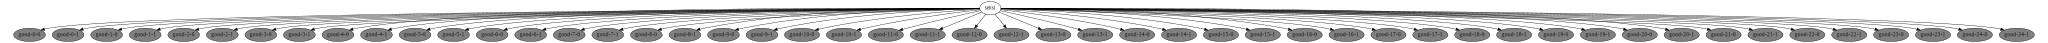

In [ ]:
numpyro.render_model(sensitivity, model_args=(2,deterministic_logs))

## Visualize Prior Distribution
- Sample and plot the prior distribution for sensitivity parameter
- Confirm the prior's shape and statistics before inference

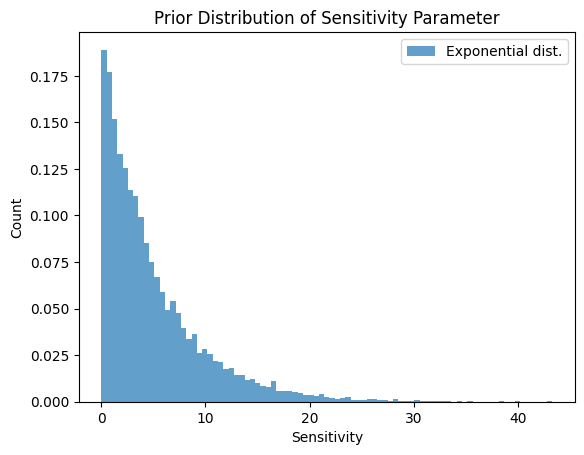

Prior Mean: 5.018049716949463
Prior Std Dev: 4.992542266845703


In [ ]:
prior_predictive = Predictive(sensitivity, num_samples=10000)

prior_samples = prior_predictive(jax.random.PRNGKey(0), nrocks=2, logs=deterministic_logs)

prior_sensi_samples = prior_samples['sensi']

plt.hist(prior_sensi_samples, bins='auto', density=True, alpha=0.7, label=f"Exponential dist.")
plt.title('Prior Distribution of Sensitivity Parameter')
plt.xlabel('Sensitivity')
plt.ylabel('Count')
plt.legend()
plt.show()

print(f"Prior Mean: {prior_sensi_samples.mean()}")
print(f"Prior Std Dev: {prior_sensi_samples.std()}")

Note that, somewhat counterintuitevely at the first sight, the sensitivity can be inferred without sampling observations at all, provided multiple sensing observations are obtained.

## MCMC Inference Setup

In [ ]:
def run_inference(model, *model_args, step_size=1.0, show_progress_bar=True):
    nuts_kernel = NUTS(model, step_size=step_size)
    mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=2, progress_bar=show_progress_bar)
    rng_key = jax.random.PRNGKey(0)
    mcmc.run(rng_key, *model_args)
    return mcmc

## Run MCMC on Deterministic Movement Data
- Infer sensitivity parameter from deterministic logs
- Analyze convergence with summary statistics

In [ ]:
mcmc = run_inference(sensitivity, 2, deterministic_logs)
mcmc.print_summary()

/tmp/ipython-input-1629041088.py:3: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=10000, num_chains=4, progress_bar=show_progress_bar)
sample: 100%|██████████| 11000/11000 [00:33<00:00, 328.14it/s, 1 steps of size 1.09e+00. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sensi      2.08      0.45      2.04      1.36      2.80  14153.02      1.00

Number of divergences: 0


## Plotting the Posterior
- Plot multiple distributions against ground truth value
- Compare posterior estimates from different inference methods

In [ ]:
def plot_sensitivity_distributions(ground_truth, distributions):
    plt.figure(figsize=(10, 6))
    title='Comparison of Posterior Distributions'

    colors = ['blue', 'orange', 'green', 'cyan', 'purple', 'brown']

    for i, (name, samples) in enumerate(distributions.items()):
        if samples is not None:
            plt.hist(samples, bins='auto', label=name, density=True,
                     alpha=0.5, color=colors[i % len(colors)])

    plt.axvline(x=ground_truth, ls='dashed', color='red', label='Ground Truth')

    plt.xlim(-1, 7)
    plt.xlabel('Sensitivity')
    plt.ylabel('Density')
    plt.legend()
    plt.title(title)
    plt.show()

## SVI

We will use SVI to infer the sensi parameter, this is done by turning the inference into an optimization problem. We minimize the KL divergence (a measure of difference) between guide(sensitivity) and P(sensitivity|obs). This is equivalent to maximizing the Evidence Lower Bound (ELBO):

$$ \text{ELBO}(λ) = E_{guideλ(sensi)}[\log \Pr(\text{obs, sensitivity})] - E[\log \text{guide(sensitivity})] $$

Where:
- guideλ is the guide distribution, with parameters $λ = \text{{sensi_loc, sensi_scale}}$ for the LogNormal dist.
- $ \Pr(\text{sensitivity, obs})$ is the joint probability from our model

\\
We will want to calculate:

$\Pr(\text{obs, sensitivity})$ - which is how likely is both this sensitivity value AND these observations together

This is equal to:

$\Pr(\text{obs, sensitivity} = \Pr(\text{sensitivity}) ⋅ \Pr(\text{obs|sensitivity})$

Extracting log from both sides:
$\log \Pr(\text{obs, sensitivity}) = \log \Pr(\text{sensitivity}) + \Pr(\text{obs|sensitivity}) $

\\
In our model:
- $\Pr(\text{sensitivity}) = \text{log prior = log(Exponential(0.1))}$
- $\log \Pr(\text{obs|sensitivity})$ is the likelihood, which equals to:
$\log \Pr (sensitivity) + \sum_{num logs} \sum_{num rocks} \log \Pr(\text{sensitivity, logs, rocks}) $

In total - we calculate how likely it is to see both our data (obs) and a specific value of sensitivity together.


## Define Variational Guide for SVI
- Parameterize sensitivity posterior with log-normal distribution
- Learnable parameters will be optimized during SVI
- Using positive constraint ensures valid scale parameter
- Returns a sensitivity sample from the variational distribution

In [ ]:
def sensitivity_guide(nrocks, logs, *model_args):
    sensi_shape = numpyro.param('sensi_shape', 2.0)
    sensi_rate = numpyro.param('sensi_rate', 0.5)

    # Sample sensi using these parameters
    sensi = numpyro.sample('sensi', dist.Gamma(sensi_shape, sensi_rate))
    return sensi

In [ ]:
# Get guide prior samples (before optimization)
init_params = {'sensi_shape': 2.0, 'sensi_rate': 0.5}
guide_predictive = Predictive(sensitivity_guide, params=init_params, num_samples=40000)
guide_samples = guide_predictive(jax.random.PRNGKey(0), nrocks=2, logs=deterministic_logs)
guide_sensi_samples = guide_samples['sensi']

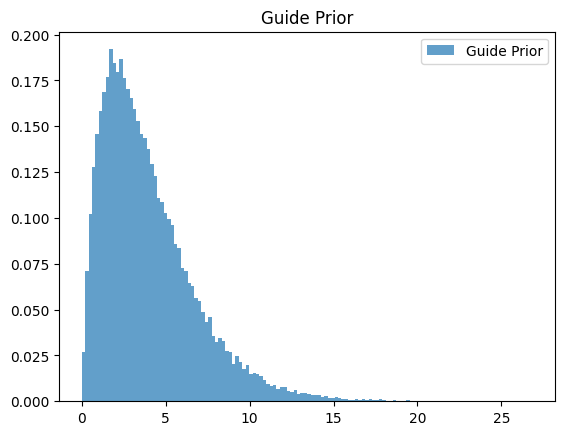

Prior Mean: 3.978651762008667
Prior Std Dev: 2.805269479751587


In [ ]:
plt.hist(guide_sensi_samples, bins='auto', alpha=0.7, density=True, label='Guide Prior')
plt.legend()
plt.title('Guide Prior')
plt.show()

print(f"Prior Mean: {guide_sensi_samples.mean()}")
print(f"Prior Std Dev: {guide_sensi_samples.std()}")

shape: 17.1161, loc: 0.2248, scale: 0.1086, rate: 9.209082


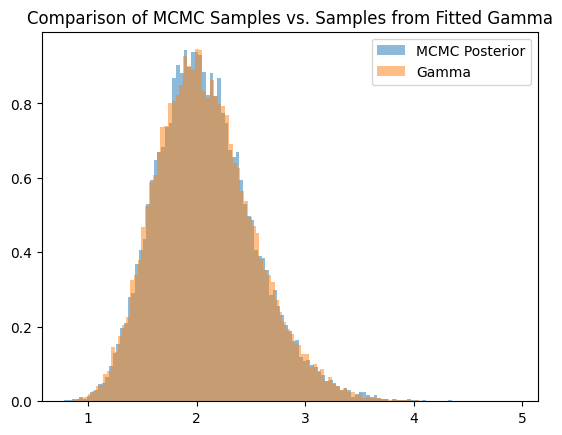

In [ ]:
mcmc_samples = mcmc.get_samples()['sensi']

shape, loc, scale = gamma.fit(mcmc_samples)
print(f"shape: {shape:.4f}, loc: {loc:.4f}, scale: {scale:.4f}, rate: {1/scale:4f}")
gamma_samples = gamma(shape, loc, scale).rvs(len(mcmc.get_samples()['sensi']))

plt.hist(mcmc_samples, bins='auto', alpha=0.5, density=True, label='MCMC Posterior')
plt.hist(gamma_samples, bins='auto', alpha=0.5, density=True, label='Gamma')
plt.legend()
plt.title('Comparison of MCMC Samples vs. Samples from Fitted Gamma')
plt.show()

In [ ]:
def run_svi(model, guide, *model_args, num_steps=10000, step_size=0.01):
    optimizer = numpyro.optim.Adam(step_size=step_size)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO(num_particles=100))

    svi_result = svi.run(jax.random.PRNGKey(int(time.time() * 1E6)), num_steps, *model_args)
    params = svi_result.params
    print("Learned parameters:", params)
    return params

### Smoke Test

Run SVI inference on determinstic logs and determinstic apply action, and compare it to MCMC posterior

In [ ]:
sensi_params = run_svi(sensitivity, sensitivity_guide, 2, deterministic_logs, num_steps=10000, step_size=0.01)

100%|██████████| 10000/10000 [00:40<00:00, 248.67it/s, init loss: 110.1955, avg. loss [9501-10000]: 104.2663]


Learned parameters: {'sensi_rate': Array(9.227984, dtype=float32), 'sensi_shape': Array(19.248327, dtype=float32)}


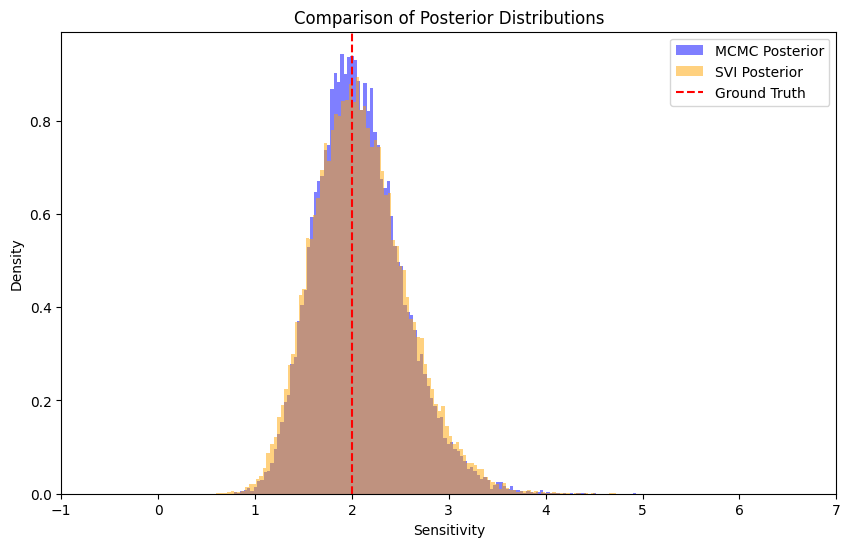

In [ ]:
distributions = {
    'MCMC Posterior': mcmc.get_samples()['sensi'],
    'SVI Posterior': dist.Gamma(sensi_params['sensi_shape'],
                                sensi_params['sensi_rate']).sample(jax.random.PRNGKey(0),
                                                                    (len(mcmc.get_samples()['sensi']),)),
}

plot_sensitivity_distributions(crawler.sensi, distributions)

## Stochastic Transition Function

Now we will try to see if our model converges with Stochastic transitions.

The Stochastic Transition model we will use adds uncertainty to the robot's movement. When the robot tries to move:
with probability prob_success it will successfully move to the desired location, and with probability 1-prob_success it will remain in its place.

This better represents real-world scenarios where movements aren't always reliable, and helps us test whether our inference still works when the environment is less predictable.

In [ ]:
def apply_action_s(action, x, y, prob_success=0.8):
    new_x, new_y = x, y
    if random.random() < prob_success:
        if action == 'right':
            new_x = min(new_x + 1, grid.width)
        elif action == 'left':
            new_x = max(new_x - 1, 0)
        elif action == 'up':
            new_y = min(new_y + 1, grid.height - 1)
        elif action == 'down':
            new_y = max(new_y - 1, 0)
    return new_x, new_y

In [ ]:
n_logs = 20
seed = 15

stochastic_logs = generate_logs(simulator, crawler, n_logs, seed, apply_action=apply_action_s, log_pos=True)

## Sensitivity Model with Transition Function

Now we will assume that we do not observe the position of the robot, but instead simulate its location by using the transition function. This allows us to track the robot's position as we process the log, updating our position estimate with each movement action.

- Model receives transition function to simulate robot movement
- Position is updated sequentially based on observed actions
- Maintains uncertainty about rock quality with logaddexp

In [ ]:
def logprob_with_trajectory(sensi, nrocks, ilog, log, trajectory):
    """Compute log probability of observations using pre-computed trajectory."""
    # Initialize log probabilities for all rocks
    rock_logp = [0.0] * nrocks
    rock_log1_p = [0.0] * nrocks

    traj_idx = 0
    x, y = log[0].p

    # process each log entry once for all rocks
    for e in log:
        # Update position using pre-computed trajectory
        if e.a in ['up', 'down', 'right', 'left']:
            traj_idx += 1
            if traj_idx < len(trajectory):
                x, y = trajectory[traj_idx]

        # Process observations
        if e.a in ['sense', 'sample']:
            rock, (x_rock, y_rock) = e.r

            # Calculate probability based on action type
            if e.a == 'sense':
                dx, dy = x - x_rock, y - y_rock
                p = 0.5 + 0.5 * jnp.exp(-(jnp.sqrt(dx * dx + dy * dy) * jnp.log(2)) / sensi)
                p = jnp.clip(p, 0.01, 0.99)
            else:  # sample
                p = 0.99

            # Update probabilities for this specific rock
            if e.o:
                rock_logp[rock] += jnp.log(p)
                rock_log1_p[rock] += jnp.log(1-p)
            else:
                rock_logp[rock] += jnp.log(1-p)
                rock_log1_p[rock] += jnp.log(p)

    # Combine all rock probabilities with their priors
    total_logp = 0.0
    for rock in range(nrocks):
        rock_posterior = jnp.logaddexp(
            rock_logp[rock] + jnp.log(0.5),
            rock_log1_p[rock] + jnp.log(0.5))
        total_logp += rock_posterior

    return total_logp

def sensitivity_with_trajectories(nrocks, logs, trajectories):
    """NumPyro model using pre-computed trajectories"""
    sensi = numpyro.sample('sensi', dist.Exponential(0.2))

    for ilog, (log, trajectory) in enumerate(zip(logs, trajectories)):
        numpyro.factor(f'log-{ilog}',
                      logprob_with_trajectory(sensi, nrocks, ilog, log, trajectory))

### MCMC Known Positions

For comparison later on, we will assume we know the robots location (it is taken from the simulator, and used for evaluation purposes only), and run MCMC inference using the known / actual robot positions.

We will input the actual robot's position as the trajectories to our sensitivity_with_trajectory model

In [ ]:
def extract_known_trajectories(logs):
    traj = [] # all trajectories, each entry is a trajectory for a specific episode
    for episode in logs:
        e_traj = [] # episode trajectory

        # Add initial position
        if episode[0].a is None:
            e_traj.append(episode[0].p)

        # Add positions from movement actions
        for step in episode:
            if step.a in ['up', 'down', 'right', 'left']:
                e_traj.append(step.p)

        traj.append(e_traj)
    return traj

In [ ]:
trajectories = extract_known_trajectories(stochastic_logs);

mcmc_known_positions = run_inference(sensitivity_with_trajectories, 2, stochastic_logs, trajectories)
mcmc_known_positions.print_summary()

/tmp/ipython-input-3439544630.py:3: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=2, progress_bar=show_progress_bar)
sample: 100%|██████████| 6000/6000 [00:27<00:00, 217.23it/s, 3 steps of size 1.07e+00. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
     sensi      2.05      0.45      2.02      1.29      2.73   3273.61      1.00

Number of divergences: 0


## Guide

We will define a guide for optimization: q($\theta$) = Gamma(2.0, 5.0)

In [ ]:
def guide(nrocks, logs, trajectories):
    sensi_mean = numpyro.param('sensi_mean', 2.0)
    sensi_vari = numpyro.param('sensi_vari', 5.0)

    sensi = numpyro.sample('sensi', dist.Gamma(
        sensi_mean * sensi_mean / sensi_vari,
        sensi_mean / sensi_vari))

    return sensi

## Generating Trajectories

We will generate trajectories using our transition model - for each episode, we will pass the logs (that include the action-observation history) and sample a realization of the robots transitions, using the initial location, and action history.

In [ ]:
def generate_trajectories(logs, apply_action):
    """Generate trajectories by simulating movement actions from logs"""
    trajectories = []

    for log in logs:
        trajectory = []

        if log[0].a is None:
            x, y = log[0].p
        trajectory.append((x, y))

        for e in log:
            if e.a in ['up', 'down', 'right', 'left']:
                x, y = apply_action(e.a, x, y)
                trajectory.append((x, y))

        trajectories.append(trajectory)

    return trajectories

In [ ]:
def svi_inference(model, guide, data, apply_action, num_steps=500):
    print("Running SVI inference...")

    optimizer = numpyro.optim.Adam(step_size=0.01)
    svi = SVI(sensitivity_with_trajectories, guide, optimizer,
              loss=Trace_ELBO(num_particles=1000))

    rng_key = jax.random.PRNGKey(int(time.time() * 1E6))

    # init
    init_traj = generate_trajectories(data, apply_action)
    svi_state = svi.init(rng_key, 2, data, init_traj)

    losses0 = jnp.zeros(num_steps)
    means0  = jnp.zeros(num_steps)
    sds0    = jnp.zeros(num_steps)

    def body_fn(i, carry):
        svi_state, losses, means, sds = carry

        trajectories = generate_trajectories(data, apply_action)
        svi_state, loss = svi.update(svi_state, 2, data, trajectories)

        params = svi.get_params(svi_state)
        mean_val = params['sensi_mean']
        sd_val   = jnp.sqrt(params['sensi_vari'])

        losses = losses.at[i].set(loss)
        means  = means.at[i].set(mean_val)
        sds    = sds.at[i].set(sd_val)

        return svi_state, losses, means, sds

    svi_state, losses, means, sds = jax.lax.fori_loop(
        0, num_steps, body_fn, (svi_state, losses0, means0, sds0)
    )

    params = svi.get_params(svi_state)
    return list(np.array(losses)), list(np.array(means)), list(np.array(sds)), params


### Smoke test

We will try to run the new svi inference (with 1. svi init, 2. generate trajectories based on logs and apply action funcition, 3. svi update)

With the deterministic logs and deterministic apply action.

This is in order to show that our sensitivity_with_trajectories infers the parameter as supposed to.

We expect our SVI inference with trajectories sampling, to be identical to the MCMC posterior

Running SVI inference...


Text(0, 0.5, 'loss')

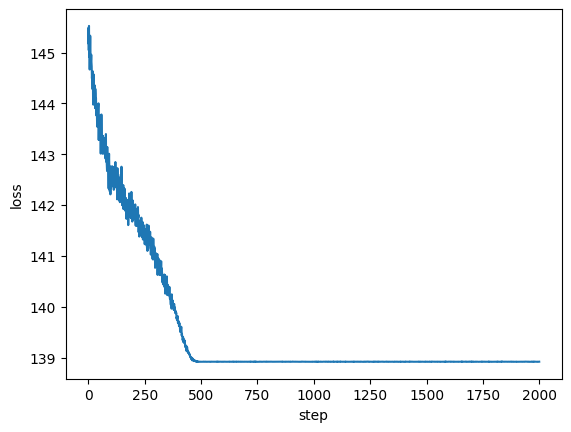

In [ ]:
losses, means, sds, params = svi_inference(sensitivity_with_trajectories, guide, deterministic_logs, apply_action_d, num_steps=2000)

plt.plot(losses)
plt.xlabel("step")
plt.ylabel("loss")

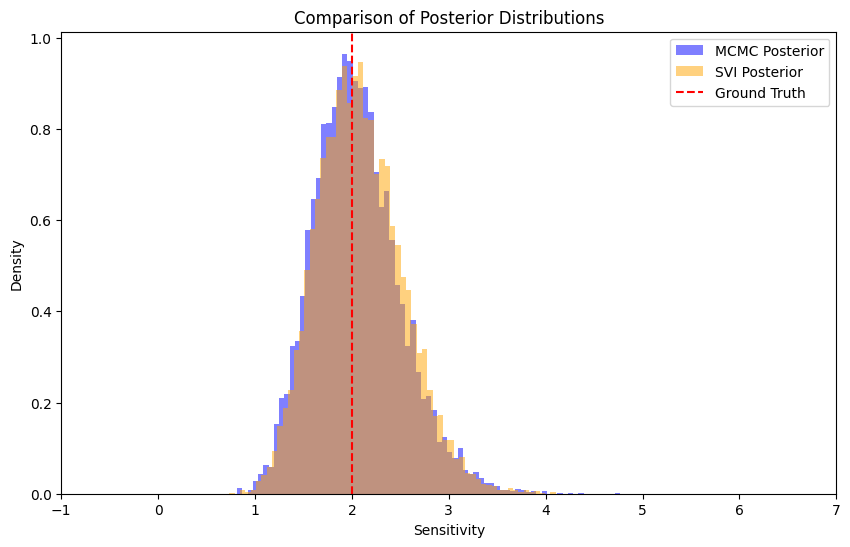

In [ ]:
# pull from final params
svi_mean = params['sensi_mean'].item()
svi_std  = np.sqrt(params['sensi_vari']).item()

# sample from Gamma approx with same number of draws as MCMC
mcmc_samples = mcmc_known_positions.get_samples()['sensi']
svi_samples = np.random.gamma(
    shape=(svi_mean**2) / (svi_std**2),
    scale=(svi_std**2) / svi_mean,
    size=len(mcmc_samples)
)

distributions = {
    'MCMC Posterior': mcmc_samples,
    'SVI Posterior': svi_samples,
}

plot_sensitivity_distributions(crawler.sensi, distributions)

## Stochastic Case

Now we will get into the interesting part, stochastic logs (meaning they were generated using the stochasitc apply action)

In [ ]:
losses, means, sds, params = svi_inference(sensitivity_with_trajectories, guide, stochastic_logs, apply_action_s, num_steps=2000)

Running SVI inference...


In [ ]:
def plot_svi_convergence_rock(losses, means, actual_value=None,
                              param_label=r"$\theta_{\text{sensitivity}}$"):
    """
    Convergence figure with text positioned just above final values.
    """
    loss_arr = np.asarray(losses, dtype=float)
    mean_arr = np.asarray(means,  dtype=float)

    # Professional styling
    plt.style.use('default')
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 6))

    # Top: ELBO with BLACK styling
    ax0.plot(loss_arr, color="black", lw=1.5, alpha=0.8)
    ax0.set_title("SVI Loss Convergence (ELBO)", fontsize=13, pad=15)
    ax0.set_xlabel("Iteration", fontsize=11)
    ax0.set_ylabel("Loss", fontsize=11)
    ax0.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    # Bottom: mean trace
    ax1.plot(mean_arr, color="steelblue", lw=2, alpha=0.9, label="SVI posterior mean")

    if actual_value is not None:
        ax1.axhline(float(actual_value), color="red", linestyle="-", lw=2.5, alpha=0.9,
                    label=f"Value in simulations: {actual_value}")

    # Position text just above final mean value
    if len(mean_arr) > 0:
        final_mean = mean_arr[-1]
        final_iteration = len(mean_arr) - 1

        # Calculate offset as 3% of the y-range
        y_range = ax1.get_ylim()[1] - ax1.get_ylim()[0]
        y_offset = y_range * 0.03

        ax1.text(final_iteration, final_mean + y_offset,
                f'Final SVI: {final_mean:.3f}',
                ha='right', va='bottom', fontsize=9, alpha=0.7)

    ax1.set_title(f"Parameter Convergence: {param_label}", fontsize=13, pad=15)
    ax1.set_xlabel("Iteration", fontsize=11)
    ax1.set_ylabel("Posterior mean", fontsize=11)
    ax1.legend(loc="best", framealpha=0.95, fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig, (ax0, ax1)


def plot_posterior_histogram_rock(final_params, means, actual_value=None,
                                 param_label=r"$\theta_{\text{sensitivity}}$", num_samples=40000,
                                 map_estimates=None, pg_samples=None):
    """
    Parameters:
    -----------
    pg_samples : array-like, optional
        Particle Gibbs posterior samples to overlay. If None, no PG overlay.
    """
    # Extract SVI posterior parameters (Gamma via mean/variance)
    mean_svi = float(np.asarray(final_params["sensi_mean"]))
    var_svi = float(np.asarray(final_params["sensi_vari"]))

    if mean_svi <= 0 or var_svi <= 0:
        raise ValueError(f"Invalid SVI moments for Gamma: mean={mean_svi}, var={var_svi}")

    # Convert to Gamma shape/scale parameters
    k_svi = (mean_svi * mean_svi) / var_svi  # shape
    theta_svi = var_svi / mean_svi          # scale
    svi_samples = np.random.gamma(shape=k_svi, scale=theta_svi, size=int(num_samples))

    # Professional styling
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create x-axis for density curves based on 99.5% credible interval
    # This avoids cramped plots with too much empty space
    svi_ci_995 = np.percentile(svi_samples, [0.25, 99.75])
    ci_range = svi_ci_995[1] - svi_ci_995[0]
    x_min = max(0, svi_ci_995[0] - 0.3 * ci_range)  # 30% padding, but Gamma support is [0, ∞)
    x_max = svi_ci_995[1] + 0.3 * ci_range

    # Adjust x-axis if PG samples provided
    if pg_samples is not None:
        pg_samples = np.array(pg_samples)
        pg_ci_995 = np.percentile(pg_samples, [0.25, 99.75])
        x_min = max(0, min(x_min, pg_ci_995[0] - 0.3 * (pg_ci_995[1] - pg_ci_995[0])))
        x_max = max(x_max, pg_ci_995[1] + 0.3 * (pg_ci_995[1] - pg_ci_995[0]))

    x = np.linspace(x_min, x_max, 200)

    # Compute and plot SVI density
    svi_kde = stats.gaussian_kde(svi_samples)
    svi_density = svi_kde(x)
    ax.fill_between(x, svi_density, alpha=0.3, color='steelblue', label='SVI posterior')
    ax.plot(x, svi_density, color='steelblue', linewidth=2)

    # Add PG posterior overlay if provided
    if pg_samples is not None:
        pg_kde = stats.gaussian_kde(pg_samples)
        pg_density = pg_kde(x)
        ax.fill_between(x, pg_density, alpha=0.2, color='orange', label='PG posterior')
        ax.plot(x, pg_density, color='orange', linewidth=2, linestyle='--')

        # PG statistics
        pg_mean = np.mean(pg_samples)
        pg_ci = np.percentile(pg_samples, [2.5, 97.5])
        ax.axvline(pg_mean, color='orange', linestyle=':', linewidth=2,
                   alpha=0.8, label=f'PG mean: {pg_mean:.3f}')

    # Add SVI vertical lines and credible intervals
    svi_mean = float(means[-1])
    svi_ci = np.percentile(svi_samples, [2.5, 97.5])

    ax.axvline(svi_mean, color='steelblue', linestyle='--', linewidth=2,
               alpha=0.8, label=f'SVI mean: {svi_mean:.3f}')
    ax.axvspan(svi_ci[0], svi_ci[1], alpha=0.1, color='steelblue')

    # Add MAP estimates if provided
    if map_estimates is not None:
        map_estimates = np.array(map_estimates)
        map_mean = np.mean(map_estimates)

        # Plot individual MAP estimates as thin vertical lines
        for i, estimate in enumerate(map_estimates):
            if i == 0:
                ax.axvline(estimate, color='green', linestyle='-', linewidth=1,
                          alpha=0.5, label='MAP estimates')
            else:
                ax.axvline(estimate, color='green', linestyle='-', linewidth=1,
                          alpha=0.5)

        # Plot MAP mean as thicker line
        ax.axvline(map_mean, color='green', linestyle='--', linewidth=2,
                   alpha=0.9, label=f'MAP mean: {map_mean:.3f}')

    # Add value in simulations line
    if actual_value is not None:
        ax.axvline(float(actual_value), color='red', linestyle='-', linewidth=2.5,
                   alpha=0.9, label=f'Value in simulations: {actual_value}')

    # Professional styling
    ax.set_xlabel(param_label, fontsize=12)
    ax.set_ylabel('Posterior density', fontsize=12)
    ax.set_title(f'Posterior Inference Results: {param_label}', fontsize=13, pad=20)
    ax.legend(loc='best', fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis limits with padding
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.show()

    # Enhanced numerical summary
    print("\n" + "="*60)
    print("POSTERIOR INFERENCE SUMMARY")
    print("="*60)
    print(f"{'Method':<12} {'Mean':<8} {'Std':<8} {'95% CI':<20} {'Mode':<8}")
    print("-" * 60)

    # SVI statistics
    svi_mode = x[np.argmax(svi_density)]
    print(f"{'SVI':<12} {svi_mean:<8.3f} {np.std(svi_samples):<8.3f} "
          f"[{svi_ci[0]:.3f}, {svi_ci[1]:.3f}] {svi_mode:<8.3f}")

    # PG statistics if provided
    if pg_samples is not None:
        pg_mean = np.mean(pg_samples)
        pg_std = np.std(pg_samples)
        pg_ci = np.percentile(pg_samples, [2.5, 97.5])
        pg_mode = x[np.argmax(pg_density)]
        print(f"{'PG':<12} {pg_mean:<8.3f} {pg_std:<8.3f} "
              f"[{pg_ci[0]:.3f}, {pg_ci[1]:.3f}] {pg_mode:<8.3f}")

    # MAP statistics if provided
    if map_estimates is not None:
        map_estimates = np.array(map_estimates)
        map_mean = np.mean(map_estimates)
        map_std = np.std(map_estimates)
        map_ci = np.percentile(map_estimates, [2.5, 97.5])
        print(f"{'MAP':<12} {map_mean:<8.3f} {map_std:<8.3f} "
              f"[{map_ci[0]:.3f}, {map_ci[1]:.3f}] {'N/A':<8}")

    # Gamma distribution properties
    print(f"\nGamma Distribution Parameters (SVI):")
    print(f"  Shape (k): {k_svi:.3f}")
    print(f"  Scale (θ): {theta_svi:.3f}")
    print(f"  Rate (β = 1/θ): {1/theta_svi:.3f}")

    if actual_value is not None:
        true_val = float(actual_value)
        svi_error = abs(svi_mean - true_val)
        print(f"\nValue in Simulations Comparison:")
        print(f"  Simulation value: {true_val:.3f}")
        print(f"  SVI error:  {svi_error:.4f}")

        if pg_samples is not None:
            pg_error = abs(pg_mean - true_val)
            print(f"  PG error:   {pg_error:.4f}")

        if map_estimates is not None:
            map_error = abs(map_mean - true_val)
            print(f"  MAP error:  {map_error:.4f}")

    print("="*60)

    return fig, ax

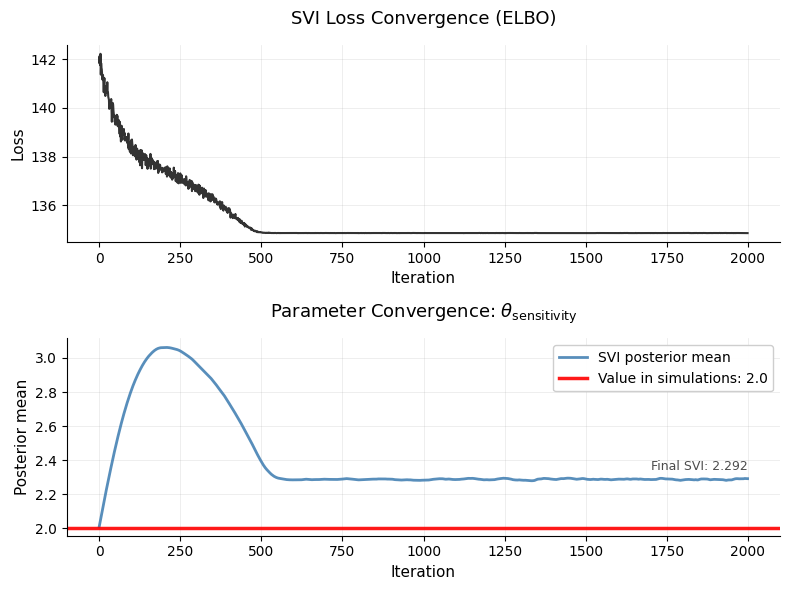

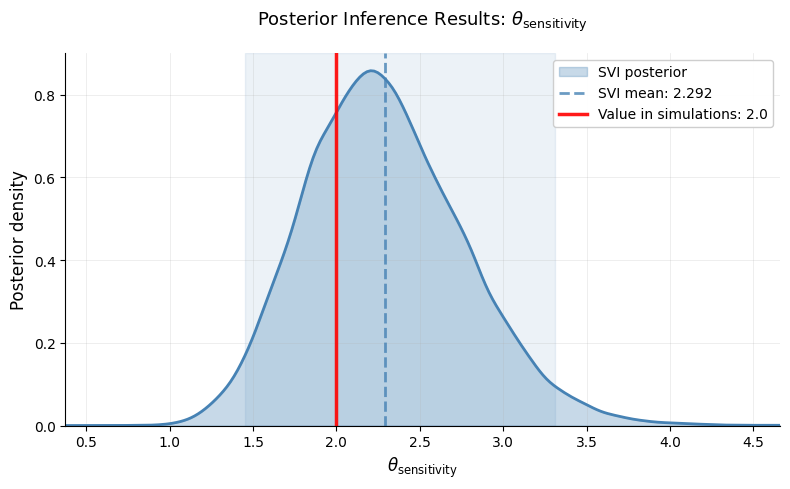


POSTERIOR INFERENCE SUMMARY
Method       Mean     Std      95% CI               Mode    
------------------------------------------------------------
SVI          2.292    0.477    [1.449, 3.310] 2.205   

Gamma Distribution Parameters (SVI):
  Shape (k): 22.995
  Scale (θ): 0.100
  Rate (β = 1/θ): 10.032

Value in Simulations Comparison:
  Simulation value: 2.000
  SVI error:  0.2921


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Inference Results: $\\theta_{\\text{sensitivity}}$'}, xlabel='$\\theta_{\\text{sensitivity}}$', ylabel='Posterior density'>)

In [ ]:
plot_svi_convergence_rock(
    losses, means,
    actual_value=2.0,
    param_label=r"$\theta_{\text{sensitivity}}$"
)

plot_posterior_histogram_rock(
    params, means,
    actual_value=2.0,
    param_label=r"$\theta_{\text{sensitivity}}$"
)

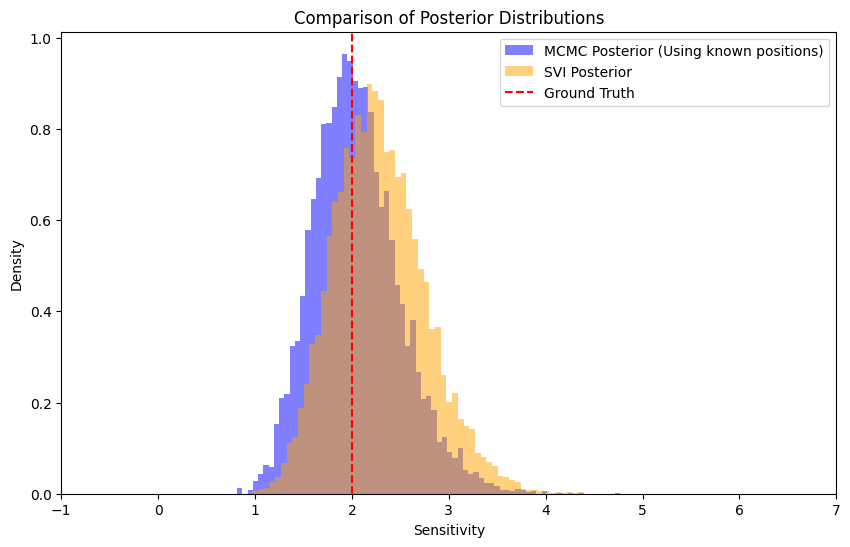

In [ ]:
# extract from final SVI params
svi_mean = params['sensi_mean'].item()
svi_std  = np.sqrt(params['sensi_vari']).item()

mcmc_samples = mcmc_known_positions.get_samples()['sensi']

# generate Gamma samples using mean/std -> shape/scale
svi_samples = np.random.gamma(
    shape=(svi_mean**2) / (svi_std**2),
    scale=(svi_std**2) / svi_mean,
    size=len(mcmc_samples)
)

distributions = {
    'MCMC Posterior (Using known positions)': mcmc_samples,
    'SVI Posterior': svi_samples,
}

plot_sensitivity_distributions(crawler.sensi, distributions)


## Various probability of success values

Quick reminder: our move action proability is determined by a parameter called p_success, in order to determine the accuracy of our inference, we will run the inference with various values for probability of moving correctly.

We will compare the SVI inference with trajectory generations to the MCMC posterior with known positions (each time infer the new posterior based on the logs generated using the p_success).

In [ ]:
prob_success_values = [0.9, 0.8, 0.7, 0.6]
results = {}
n_logs = 20

for prob_success in prob_success_values:
    print(f"Running Inference with prob_success = {prob_success}")

    apply_action_fn = lambda a, x, y: apply_action_s(a, x, y, prob_success=prob_success)
    logs = generate_logs(simulator, crawler, n_logs, apply_action=apply_action_fn, log_pos=True)

    trajectories = extract_known_trajectories(logs)

    print("Running MCMC")
    mcmc = run_inference(sensitivity_with_trajectories, 2, logs, trajectories)
    mcmc_samples = mcmc.get_samples()['sensi']

    print("Running SVI")
    losses, means, sds, final_params = svi_inference(sensitivity_with_trajectories, guide, logs, apply_action_fn, num_steps=1000)

    results[prob_success] = {
        'mcmc_samples': mcmc_samples,
        'svi_losses': losses,
        'svi_means': means,
        'svi_sds': sds,
        'svi_final_params': final_params
    }

fig, axes = plt.subplots(len(prob_success_values), 2, figsize=(12, 3*len(prob_success_values)))

for i, prob_success in enumerate(prob_success_values):
    result = results[prob_success]

    ax_left = axes[i, 0]

    # MCMC samples
    ax_left.hist(result['mcmc_samples'], bins='auto', alpha=0.6, density=True, label='MCMC', color='red')

    # Sample from SVI posterior and plot
    svi_mean = result['svi_final_params']['sensi_mean']
    svi_std = np.sqrt(result['svi_final_params']['sensi_vari'])
    svi_samples = np.random.gamma(svi_mean**2/svi_std**2, svi_std**2/svi_mean, len(result['mcmc_samples']))
    ax_left.hist(svi_samples, bins='auto', alpha=0.6, density=True,
                label='SVI', color='blue')

    ax_left.axvline(x=crawler.sensi, ls='--', color='black', alpha=0.7, label='Actual Value')
    ax_left.set_title(f'Posterior Comparison (p={prob_success})')
    ax_left.set_xlabel('Sensitivity')
    ax_left.set_ylabel('Density')
    ax_left.legend()

    ax_right = axes[i, 1]

    ax_right.plot(result['svi_means'], label='SVI Mean', color='blue')
    ax_right.plot(result['svi_sds'], label='SVI Std', color='blue', linestyle='--')

    mcmc_mean = result['mcmc_samples'].mean()
    mcmc_std = result['mcmc_samples'].std()
    ax_right.axhline(y=mcmc_mean, color='red', linestyle='-', alpha=0.7, label='MCMC Mean')
    ax_right.axhline(y=mcmc_std, color='red', linestyle='--', alpha=0.7, label='MCMC Std')
    ax_right.axhline(y=1.0, color='black', linestyle=':', alpha=0.7, label='Actual Value')

    ax_right.set_title(f'Convergence (p={prob_success})')
    ax_right.set_xlabel('SVI Steps')
    ax_right.set_ylabel('Value')
    ax_right.legend()

plt.tight_layout()
plt.show()

Running Inference with prob_success = 0.9
Running MCMC


/tmp/ipython-input-3439544630.py:3: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=2, progress_bar=show_progress_bar)
  0%|          | 0/6000 [00:00<?, ?it/s]


KeyboardInterrupt: 

# Benchmarks

Running benchmarks for SVI inference timing

In [ ]:
def benchmark_rocksample_svi(svi_inference_func, model, guide, data, apply_action, num_steps=2000, num_runs=10):
    print(f"\nBenchmarking RockSample POMDP SVI Inference...")
    print(f"Configuration: {num_steps} iterations, {num_runs} independent runs")
    print(f"Running timing benchmark...")
    print("-" * 40)

    times = []

    for run in range(num_runs):
        print(f"Run {run+1:2d}/{num_runs}: ", end="", flush=True)

        # Clear JAX caches for consistent timing
        jax.clear_caches()

        # Time the inference
        start_time = time.time()

        # Call your SVI inference function with RockSample signature
        losses, means, sds, params = svi_inference_func(model, guide, data, apply_action, num_steps)

        end_time = time.time()

        run_time = end_time - start_time
        times.append(run_time)

        print(f"{run_time:6.2f}s")

    times = np.array(times)

    # Calculate statistics
    stats = {
        'mean': np.mean(times),
        'std': np.std(times),
        'min': np.min(times),
        'max': np.max(times),
        'median': np.median(times),
        'times': times,
        'num_steps': num_steps,
        'num_runs': num_runs
    }

    # Print results
    print("-" * 40)
    print("ROCKSAMPLE POMDP TIMING RESULTS")
    print("-" * 40)
    print(f"Mean ± Std:  {stats['mean']:6.2f} ± {stats['std']:5.2f} seconds")
    print(f"Median:      {stats['median']:6.2f} seconds")
    print(f"Range:       [{stats['min']:5.2f}, {stats['max']:5.2f}] seconds")
    print(f"Per iteration: {stats['mean']/num_steps*1000:5.1f} ms/iteration")
    print("-" * 40)

    # LaTeX output for thesis
    print("\nLATEX TABLE ROW:")
    print(f"RockSample POMDP & ${stats['mean']:.1f} \\pm {stats['std']:.1f}$ & ${stats['mean']/num_steps*1000:.1f}$ \\\\")

    return stats

def plot_timing_results(stats):
    """Plot timing results for analysis."""
    import matplotlib.pyplot as plt

    times = stats['times']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Box plot
    ax1.boxplot([times], labels=['RockSample SVI'])
    ax1.set_ylabel('Time (seconds)')
    ax1.set_title('Timing Distribution')
    ax1.grid(True, alpha=0.3)

    # Time series
    ax2.plot(range(1, len(times)+1), times, 'o-', alpha=0.7)
    ax2.axhline(np.mean(times), color='red', linestyle='--',
                label=f'Mean: {np.mean(times):.2f}s')
    ax2.fill_between(range(1, len(times)+1),
                     np.mean(times) - np.std(times),
                     np.mean(times) + np.std(times),
                     alpha=0.2, color='red')
    ax2.set_xlabel('Run Number')
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Timing Across Runs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


Benchmarking RockSample POMDP SVI Inference...
Configuration: 2000 iterations, 10 independent runs
Running timing benchmark...
----------------------------------------
Run  1/10: Running SVI inference...
 35.00s
Run  2/10: Running SVI inference...
 23.23s
Run  3/10: Running SVI inference...
 21.50s
Run  4/10: Running SVI inference...
 21.68s
Run  5/10: Running SVI inference...
 27.62s
Run  6/10: Running SVI inference...
 24.13s
Run  7/10: Running SVI inference...
 22.28s
Run  8/10: Running SVI inference...
 29.45s
Run  9/10: Running SVI inference...
 30.01s
Run 10/10: Running SVI inference...
 34.01s
----------------------------------------
ROCKSAMPLE POMDP TIMING RESULTS
----------------------------------------
Mean ± Std:   26.89 ±  4.81 seconds
Median:       25.87 seconds
Range:       [21.50, 35.00] seconds
Per iteration:  13.4 ms/iteration
----------------------------------------

LATEX TABLE ROW:
RockSample POMDP & $26.9 \pm 4.8$ & $13.4$ \\


/tmp/ipython-input-2804798471.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([times], labels=['RockSample SVI'])


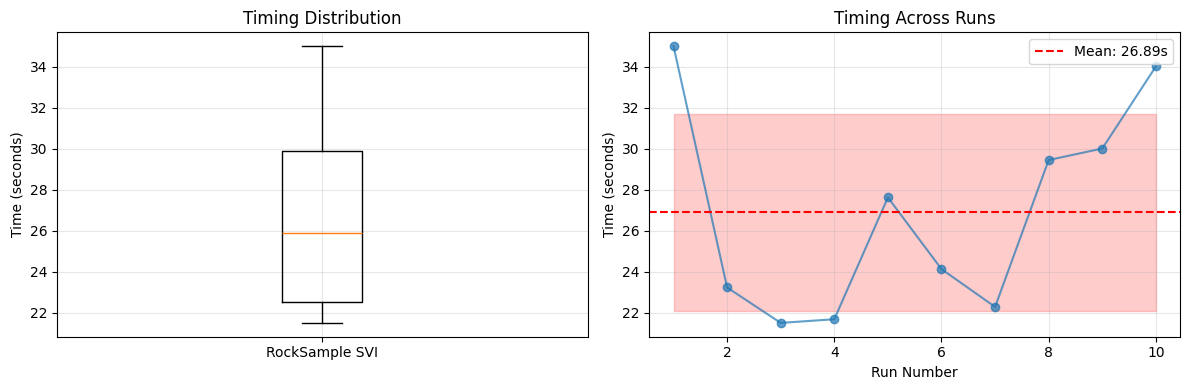

In [ ]:
rocksample_stats = benchmark_rocksample_svi(
    svi_inference_func=svi_inference,
    model=sensitivity_with_trajectories,
    guide=guide,
    data=stochastic_logs,
    apply_action=apply_action_s,
    num_steps=2000,
    num_runs=10
)

plot_timing_results(rocksample_stats)

# Baselines

Lets define certain baselines in order to compare our algorithm with

## EM

In [ ]:
def sample_trajectories(log, apply_action, n_samples=100):
    trajectories = []
    for _ in range(n_samples):
        trajectory = []
        if log[0].a is None:
            x, y = log[0].p
        trajectory.append((x, y))

        for e in log:
            if e.a in ['up', 'down', 'right', 'left']:
                x, y = apply_action(e.a, x, y)
                trajectory.append((x, y))

        trajectories.append(trajectory)
    return trajectories

def compute_trajectory_weights(log, trajectories, sensitivity):
    log_ws = []
    for traj in trajectories:
        lp = logprob_with_trajectory(sensitivity, NROCKS, 0, log, traj)
        log_ws.append(float(lp))
    log_ws = np.asarray(log_ws, dtype=np.float64)

    if not np.isfinite(log_ws).any():
        return np.ones_like(log_ws) / len(log_ws)

    m = np.max(log_ws)
    ws = np.exp(log_ws - m)
    s = ws.sum()
    if s <= 1e-300:
        return np.ones_like(ws) / len(ws)
    else:
        w = ws / s
        return w / w.sum()

def select_multiple_trajectories(trajectories, weights, k=5):
    """Select top K trajectories based on weights"""
    top_indices = np.argsort(weights)[-k:]  # Top K highest weights
    selected_trajs = [trajectories[i] for i in top_indices]
    selected_weights = weights[top_indices]
    selected_weights = selected_weights / selected_weights.sum()  # Renormalize
    return selected_trajs, selected_weights

def em_algorithm(logs, apply_action, n_samples=20, max_iterations=20, k_trajectories=5, show_prints=True):
    sensitivity = np.random.uniform(1.0, 5.0)
    history = [sensitivity]

    if show_prints:
        print(f"EM with MAP: sampling {n_samples} trajectories, using top {k_trajectories} per episode")

    # Sample trajectories once
    all_trajectories = [sample_trajectories(log, apply_action, n_samples) for log in logs]

    converged = False

    for iteration in range(max_iterations):
        if show_prints:
            print(f"\nIteration {iteration + 1}: sensitivity = {sensitivity:.4f}")

        # E-step: reweight trajectories
        all_weights = [compute_trajectory_weights(log, trajs, sensitivity)
                      for log, trajs in zip(logs, all_trajectories)]

        # Select top K trajectories per episode
        selected_trajectories = []
        selected_weights = []
        for trajs, weights in zip(all_trajectories, all_weights):
            sel_trajs, sel_weights = select_multiple_trajectories(trajs, weights, k_trajectories)
            selected_trajectories.append(sel_trajs)
            selected_weights.append(sel_weights)

        # M-step: weighted MAP estimation
        def neg_log_likelihood(sens):
            if sens <= 0.01:
                return 1e10

            total = 0.0
            for log, trajs, weights in zip(logs, selected_trajectories, selected_weights):
                episode_ll = 0.0
                for traj, weight in zip(trajs, weights):
                    episode_ll += weight * logprob_with_trajectory(sens, NROCKS, 0, log, traj)
                total += episode_ll

            # Add prior: Exponential(0.2)
            prior_ll = jnp.log(0.2) - 0.2 * sens
            return -(total + prior_ll)

        result = minimize_scalar(neg_log_likelihood, bounds=(sensitivity*0.5, sensitivity*2), method='bounded')
        new_sensitivity = result.x
        if show_prints:
            print(f"  New sensitivity: {new_sensitivity:.4f}")
            print(f"  Change: {abs(new_sensitivity - sensitivity):.6f}")

        if abs(new_sensitivity - sensitivity) < 1e-4:
            print(f"  Converged after {iteration + 1} iterations")
            converged = True
            break

        sensitivity = new_sensitivity
        history.append(sensitivity)

    if not converged:
        print("  Did not converge.")

    print(f"last value: {history[-1]:.4f}")
    return history

EM with MAP: sampling 100 trajectories, using top 1 per episode

Iteration 1: sensitivity = 3.8649
  New sensitivity: 2.1928
  Change: 1.672086

Iteration 2: sensitivity = 2.1928
  New sensitivity: 2.1292
  Change: 0.063601

Iteration 3: sensitivity = 2.1292
  New sensitivity: 2.1078
  Change: 0.021429

Iteration 4: sensitivity = 2.1078
  New sensitivity: 2.1083
  Change: 0.000499

Iteration 5: sensitivity = 2.1083
  New sensitivity: 2.1096
  Change: 0.001240

Iteration 6: sensitivity = 2.1096
  New sensitivity: 2.1090
  Change: 0.000601

Iteration 7: sensitivity = 2.1090
  New sensitivity: 2.1084
  Change: 0.000582

Iteration 8: sensitivity = 2.1084
  New sensitivity: 2.1065
  Change: 0.001895

Iteration 9: sensitivity = 2.1065
  New sensitivity: 2.1077
  Change: 0.001186

Iteration 10: sensitivity = 2.1077
  New sensitivity: 2.1081
  Change: 0.000429

Iteration 11: sensitivity = 2.1081
  New sensitivity: 2.1099
  Change: 0.001856

Iteration 12: sensitivity = 2.1099
  New sensitivity:

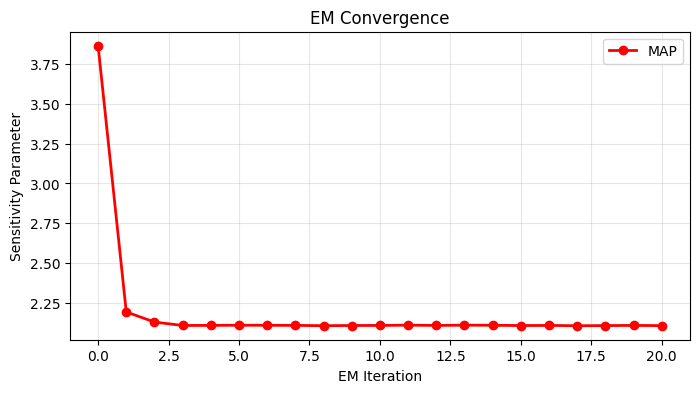

In [ ]:
map_history = em_algorithm(stochastic_logs, apply_action_s, k_trajectories=1)

print(f"\nResults:")
print(f"MAP:  {map_history[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(map_history, 'r-o', label='MAP', linewidth=2)
plt.xlabel('EM Iteration')
plt.ylabel('Sensitivity Parameter')
plt.title('EM Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
map_estimates = []
n_iterations = 10

for run in range(n_iterations):
    print(f"Run {run+1}/{n_iterations}")
    history = em_algorithm(stochastic_logs, apply_action_s, k_trajectories=1, show_prints=False)
    map_estimates.append(history[-1])

map_estimates = np.array(map_estimates)

Run 1/10
  Converged after 20 iterations
last value: 2.1835
Run 2/10
  Did not converge.
last value: 2.1951
Run 3/10
  Converged after 6 iterations
last value: 2.0626
Run 4/10
  Converged after 15 iterations
last value: 2.1329
Run 5/10
  Converged after 3 iterations
last value: 2.2036
Run 6/10
  Converged after 6 iterations
last value: 2.0959
Run 7/10
  Converged after 7 iterations
last value: 2.1937
Run 8/10
  Did not converge.
last value: 2.1715
Run 9/10
  Converged after 3 iterations
last value: 2.1516
Run 10/10
  Converged after 6 iterations
last value: 2.1434


## Particle MCMC

In [ ]:
def csmc(particles, retained=None):
    """Conditional SMC. When retained is None, unconditional. Arguments:
        * particles - vector of particles
        * retained - steps of retained particle (at index 0)
    """
    steps = [[] for _ in particles]

    while not particles[0].done:
        for particle in particles:
            particle.step()
        if retained is not None:
            particles[0] = retained.pop(0)
        for i in range(len(particles)):
            steps[i].append(copy(particles[i]))
        indices = np.random.choice(
            len(particles), size=len(particles),
            p=softmax([particle.log_prob for particle in particles]))
        particles = [particles[i].renew() for i in indices]

    for particle in particles:
        assert particle.done, "not all particles terminated at the same time"

    retained = steps[random.randint(0, len(steps) - 1)]
    return particles, retained


def pgibbs(mkparticle, nparticles, niter, collect=None):
    """Particle MCMC (Gibbs) loop.
    """
    retained = None
    for iter in tqdm.trange(niter):
        particles = [mkparticle() for _ in range(nparticles)]
        particles, retained = csmc(particles, retained)
        if collect is not None:
            collect(particles)
    return particles

In [ ]:
class Particle():
    def __init__(self, log_prob=0):
        self.log_prob = log_prob
        self.done = False

    def step(self):
        pass

    def renew(self):
        particle = copy(self)
        particle.log_prob = 0
        return particle

In [ ]:
class RockSampleParticle(Particle):
    def __init__(self,
                 move,
                 height,
                 nrocks,
                 logs,
                 log_prob=0):
        super().__init__(log_prob)

        self.move = move
        self.height = height
        self.nrocks = nrocks
        self.logs = [[]] + logs  # sentinel at the beggining
                                 # to trigger a new episode
        self.sensi = expon(scale=5).rvs()

    def step(self):
        log, logs = self.logs[0], self.logs[1:]
        if not log:
            # remove finished episode
            self.logs = self.logs[1:]
            log, logs = self.logs[0], self.logs[1:]

            # new episode
            self.x = 0
            self.y = random.randint(0, self.height - 1)
            self.rocks = stats.bernoulli(p=0.5).rvs(size=self.nrocks)

        entry, log = log[0], log[1:]
        if not log and not logs:  # last entry of last episode
            self.done = True
        self.logs = [log] + logs

        match entry.a:
            case 'right' | 'up' | 'down' | 'left':  # moving
                self.x, self.y = self.move(entry.a, self.x, self.y)
            case 'sense' | 'sample':             # weighing
                irock, (xrock, yrock) = entry.r
                if entry.a == 'sense':
                    dx, dy = self.x - xrock, self.y - yrock
                    p = 0.5 + 0.5 * np.exp(
                        -(np.sqrt(dx * dx + dy * dy) * np.log(2)) / self.sensi)
                    p = np.clip(p, 0.01, 0.99)
                else:    # sample
                    p = 0.99
                if self.rocks[irock] == entry.o:   # true observation
                    self.log_prob += np.log(p)
                else:
                    # false observation
                    self.log_prob += np.log(1 - p)

In [ ]:
NPARTICLES = 1000
NITER = 100

apply_action_fn = lambda a, x, y: apply_action_s(a, x, y, prob_success=prob_success)
mkparticle = lambda: RockSampleParticle(apply_action_fn, HEIGHT, NROCKS, logs)

sensis = []
def collect(particles):
    global sensis
    sensis.extend([p.sensi for p in particles])

pgibbs(mkparticle, NPARTICLES, niter=NITER, collect=collect)

sensis = np.array(sensis)

 92%|█████████▏| 92/100 [29:49<02:35, 19.44s/it]

In [ ]:
losses, means, sds, params = svi_inference(sensitivity_with_trajectories, guide, stochastic_logs, apply_action_s, num_steps=2000)

In [ ]:
plot_posterior_histogram_rock(
    params,
    means,
    actual_value=2.0,
    map_estimates=map_estimates,
    pg_samples=sensis
)